In [1]:
!pip install -q albumentations nibabel torchmetrics

In [2]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import h5py  # <-- ADDED for .h5 files
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# Configuration
CONFIG = {
    # Updated path based on your Kaggle screenshot
    "DATA_PATH": "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data",
    "IMAGE_SIZE": 128,
    "BATCH_SIZE": 32,
    "EPOCHS": 15,
    "LEARNING_RATE": 1e-3,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu"
}

In [3]:
def get_patient_data(base_path):
    # Find all .h5 slice files directly in the directory
    h5_files = glob.glob(os.path.join(base_path, "*.h5"))
    return h5_files

class BraTSDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        file_path = self.data_list[idx]
        
        # Read the .h5 file
        with h5py.File(file_path, 'r') as f:
            image = np.array(f['image'])
            mask = np.array(f['mask'])
            
        # 1. Extract FLAIR channel
        # Standard .h5 BraTS sets have shape (240, 240, 4) -> [FLAIR, T1w, T1gd, T2w]
        if image.ndim == 3 and image.shape[-1] == 4:
            flair_img = image[:, :, 0] 
        elif image.ndim == 3 and image.shape[0] == 4:
            flair_img = image[0, :, :]
        else:
            flair_img = image 
            
        # 2. Combine multi-class mask into binary mask
        if mask.ndim == 3:
            mask_img = np.max(mask, axis=-1)
        else:
            mask_img = mask
            
        mask_img[mask_img > 0] = 1.0
        
        flair_img = np.array(flair_img, dtype=np.float32)
        mask_img = np.array(mask_img, dtype=np.float32)
        
        # Normalize FLAIR
        if np.max(flair_img) > 0:
            flair_img = flair_img / np.max(flair_img)
            
        if self.transform:
            augmented = self.transform(image=flair_img, mask=mask_img)
            flair_img = augmented['image']
            mask_img = augmented['mask']
        else:
            flair_img = torch.from_numpy(flair_img).unsqueeze(0)
            mask_img = torch.from_numpy(mask_img).unsqueeze(0)
            
        return flair_img, mask_img

# Splitting data 70/15/15
all_data = get_patient_data(CONFIG["DATA_PATH"])

# Safety check so we don't fail silently again
if len(all_data) == 0:
    raise ValueError(f"No .h5 files found in {CONFIG['DATA_PATH']}. Please double-check the path using the Kaggle file explorer on the right!")

train_data, temp_data = train_test_split(all_data, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train slices: {len(train_data)} | Val slices: {len(val_data)} | Test slices: {len(test_data)}")

# Data Augmentation
train_transform = A.Compose([
    A.Resize(CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"]),
    ToTensorV2()
])

train_loader = DataLoader(BraTSDataset(train_data, train_transform), batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=2)
val_loader = DataLoader(BraTSDataset(val_data, val_test_transform), batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2)
test_loader = DataLoader(BraTSDataset(test_data, val_test_transform), batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2)

Train slices: 40036 | Val slices: 8579 | Test slices: 8580


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            
            # Handle resizing if dimensions don't match perfectly
            if x.shape != skip_connection.shape:
                x = nn.functional.interpolate(x, size=skip_connection.shape[2:], mode="bilinear", align_corners=True)
                
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return torch.sigmoid(self.final_conv(x))

model = UNet(in_channels=1, out_channels=1).to(CONFIG["DEVICE"])

In [5]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets, smooth=1e-6):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        # BCE
        bce_loss = self.bce(inputs, targets)
        
        # Dice
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        
        return bce_loss + dice_loss

def calculate_metrics(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection
    
    iou = (intersection + smooth) / (union + smooth)
    dice = (2. * intersection + smooth) / (pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + smooth)
    
    return iou.mean().item(), dice.mean().item()

criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["LEARNING_RATE"])

Epoch 15/15 - Val: 100%|██████████| 269/269 [01:36<00:00,  2.78it/s, dice=0.938, loss=0.196]


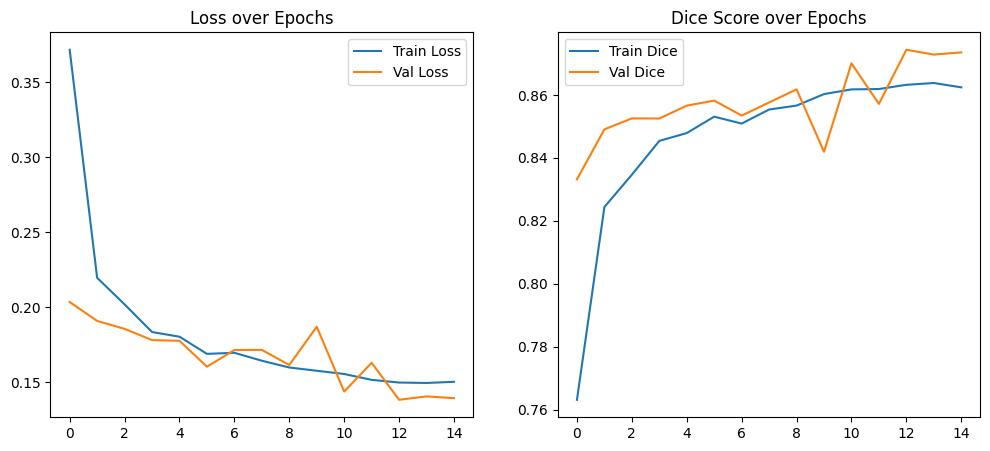

In [6]:
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(CONFIG["EPOCHS"]):
    # Training Phase
    model.train()
    running_loss, running_dice = 0.0, 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['EPOCHS']} - Train")
    for images, masks in loop:
        images, masks = images.to(CONFIG["DEVICE"]).float(), masks.to(CONFIG["DEVICE"]).float()
        
        # Since transforms might strip the channel dimension:
        if images.dim() == 3: images = images.unsqueeze(1)
        if masks.dim() == 3: masks = masks.unsqueeze(1)
            
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        _, dice = calculate_metrics(outputs, masks)
        running_loss += loss.item()
        running_dice += dice
        loop.set_postfix(loss=loss.item(), dice=dice)
        
    train_losses.append(running_loss / len(train_loader))
    train_dices.append(running_dice / len(train_loader))
    
    # Validation Phase
    model.eval()
    val_loss, val_dice = 0.0, 0.0
    with torch.no_grad():
        loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{CONFIG['EPOCHS']} - Val")
        for images, masks in loop:
            images, masks = images.to(CONFIG["DEVICE"]).float(), masks.to(CONFIG["DEVICE"]).float()
            if images.dim() == 3: images = images.unsqueeze(1)
            if masks.dim() == 3: masks = masks.unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, masks)
            _, dice = calculate_metrics(outputs, masks)
            
            val_loss += loss.item()
            val_dice += dice
            loop.set_postfix(loss=loss.item(), dice=dice)
            
    val_losses.append(val_loss / len(val_loader))
    val_dices.append(val_dice / len(val_loader))

# Plot Learning Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_dices, label='Train Dice')
plt.plot(val_dices, label='Val Dice')
plt.title('Dice Score over Epochs')
plt.legend()
plt.show()

# Save the final model weights
torch.save(model.state_dict(), "unet_brats.pth")

Testing: 100%|██████████| 269/269 [01:49<00:00,  2.46it/s]

Test IoU:  0.8351 ± 0.2838
Test Dice: 0.8691 ± 0.2701



/tmp/ipykernel_23/4082297550.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([test_ious, test_dices], labels=['IoU', 'Dice'])


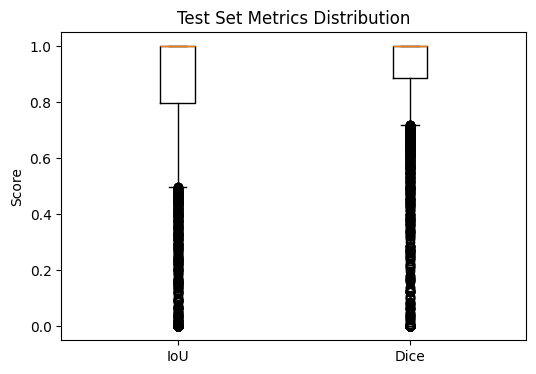

In [7]:
model.eval()
test_ious, test_dices = [], []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images, masks = images.to(CONFIG["DEVICE"]).float(), masks.to(CONFIG["DEVICE"]).float()
        if images.dim() == 3: images = images.unsqueeze(1)
        if masks.dim() == 3: masks = masks.unsqueeze(1)
            
        outputs = model(images)
        
        # Calculate per-batch metrics, iterating to get per-image metrics
        preds = (outputs > 0.5).float()
        for p, t in zip(preds, masks):
            intersection = (p * t).sum()
            union = p.sum() + t.sum() - intersection
            
            iou = (intersection + 1e-6) / (union + 1e-6)
            dice = (2. * intersection + 1e-6) / (p.sum() + t.sum() + 1e-6)
            
            test_ious.append(iou.item())
            test_dices.append(dice.item())

print(f"Test IoU:  {np.mean(test_ious):.4f} ± {np.std(test_ious):.4f}")
print(f"Test Dice: {np.mean(test_dices):.4f} ± {np.std(test_dices):.4f}")

# Boxplot for variance analysis
plt.figure(figsize=(6, 4))
plt.boxplot([test_ious, test_dices], labels=['IoU', 'Dice'])
plt.title('Test Set Metrics Distribution')
plt.ylabel('Score')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18951069..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07562067..0.9900321].


Displaying qualitative results on the Test set...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06928113..0.9449117].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1063376..1.0].


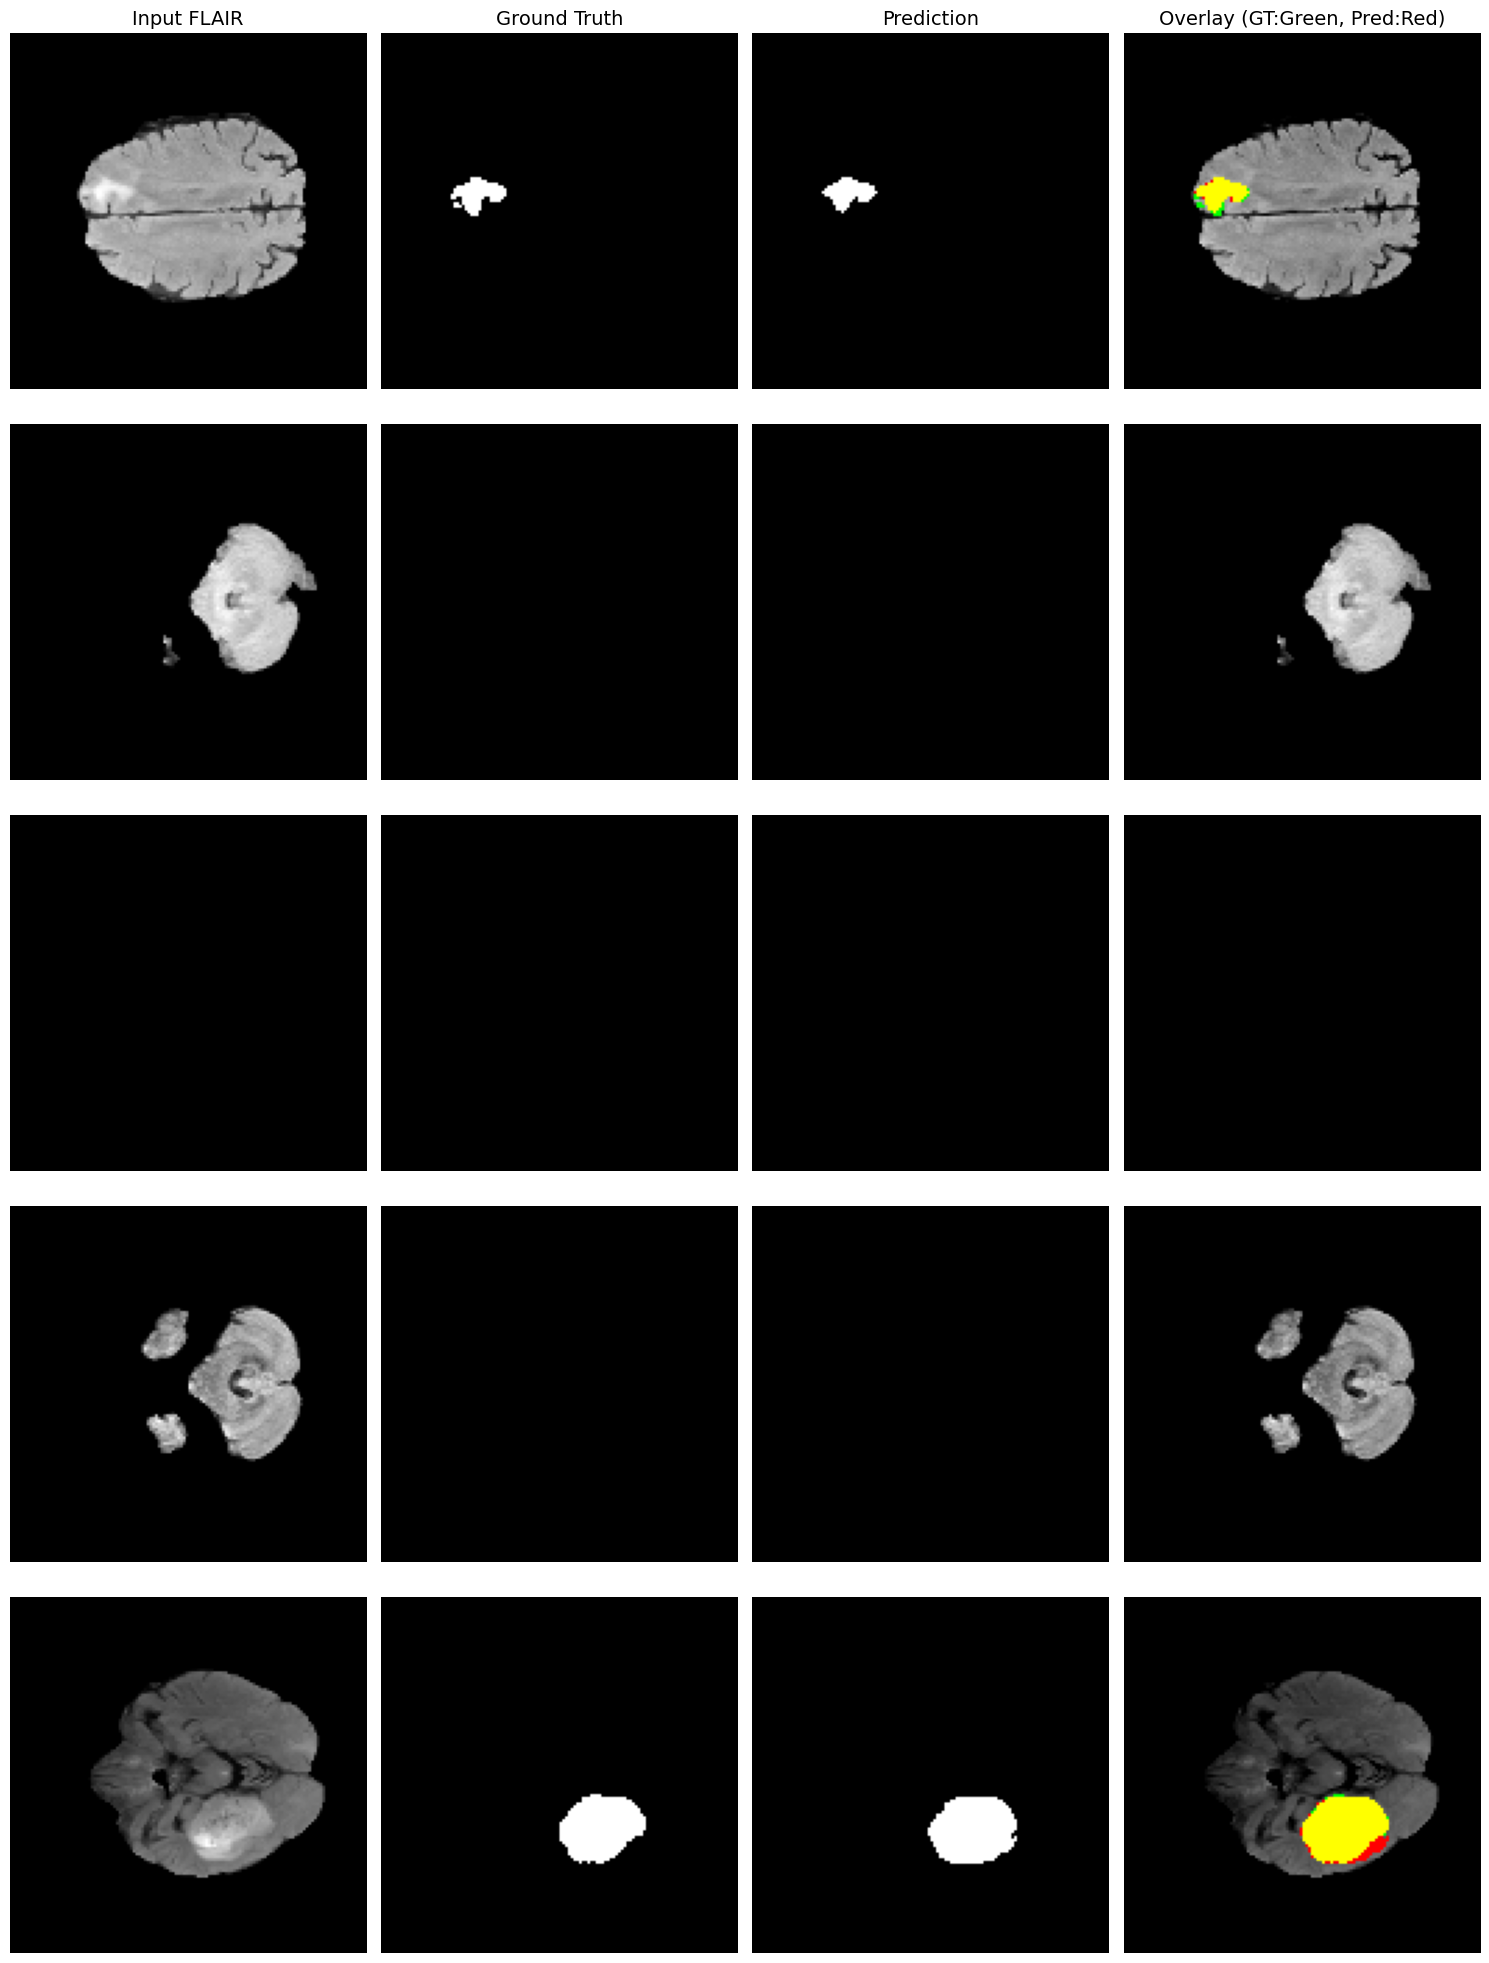

In [8]:
def visualize_predictions(dataset, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(15, 4*num_samples))
    axes[0, 0].set_title("Input FLAIR", fontsize=14)
    axes[0, 1].set_title("Ground Truth", fontsize=14)
    axes[0, 2].set_title("Prediction", fontsize=14)
    axes[0, 3].set_title("Overlay (GT:Green, Pred:Red)", fontsize=14)
    
    with torch.no_grad():
        for i in range(num_samples):
            # Pick random samples
            idx = random.randint(0, len(dataset) - 1)
            image, mask = dataset[idx]
            
            # Prepare image for model
            img_tensor = image.unsqueeze(0).to(CONFIG["DEVICE"]).float()
            if img_tensor.dim() == 3: img_tensor = img_tensor.unsqueeze(1)
                
            pred = model(img_tensor)
            pred = (pred > 0.5).squeeze().cpu().numpy()
            
            img_np = image.squeeze().numpy()
            mask_np = mask.squeeze().numpy()
            
            # Create RGB overlay
            overlay = np.stack((img_np, img_np, img_np), axis=-1)
            # Add ground truth in Green
            overlay[mask_np == 1] = [0, 1, 0]
            # Add prediction in Red
            overlay[pred == 1] = [1, 0, 0]
            # Intersection becomes Yellow ([1,1,0])
            overlay[(mask_np == 1) & (pred == 1)] = [1, 1, 0]
            
            axes[i, 0].imshow(img_np, cmap='gray')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_np, cmap='gray')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred, cmap='gray')
            axes[i, 2].axis('off')
            
            axes[i, 3].imshow(overlay)
            axes[i, 3].axis('off')
            
    plt.tight_layout()
    plt.show()

print("Displaying qualitative results on the Test set...")
visualize_predictions(BraTSDataset(test_data, val_test_transform), num_samples=5)

In [9]:
from IPython.display import FileLink
FileLink(r'unet_brats.pth')

/kaggle/working/unet_brats.pth